In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [15]:
# Load everything

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # visualizations
import os

In [18]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv
/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv


In [21]:
df = pd.read_csv("/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv", nrows=500000)

In [22]:
df.head()
df.shape

(500000, 9)

In [23]:
df['event_type'].value_counts()

event_type
view        481833
purchase      9758
cart          8409
Name: count, dtype: int64

In [24]:
event_counts = df['event_type'].value_counts()

views = event_counts.get('view', 0)
cart = event_counts.get('cart', 0)
purchase = event_counts.get('purchase', 0)

print("View → Cart:", cart/views)
print("Cart → Purchase:", purchase/cart)

View → Cart: 0.017452104774890887
Cart → Purchase: 1.1604233559281723


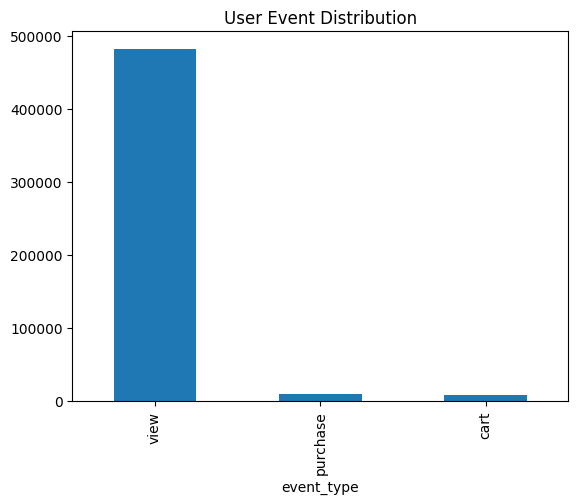

In [25]:
import matplotlib.pyplot as plt

event_counts.plot(kind='bar')
plt.title("User Event Distribution")
plt.show()

In [26]:
top_categories = df['category_code'].value_counts().head(10)
print(top_categories)

category_code
electronics.smartphone              137997
electronics.clocks                   16221
computers.notebook                   14381
electronics.audio.headphone          13140
electronics.video.tv                 10562
appliances.kitchen.refrigerators      9158
appliances.environment.vacuum         9092
apparel.shoes                         7891
appliances.kitchen.washer             7741
auto.accessories.player               6002
Name: count, dtype: int64


In [27]:
cart_users = set(df[df['event_type']=='cart']['user_id'])
purchase_users = set(df[df['event_type']=='purchase']['user_id'])

drop_off_users = cart_users - purchase_users

print("Users who added to cart but didn't purchase:", len(drop_off_users))

Users who added to cart but didn't purchase: 1686


In [28]:
top_products = df[df['event_type']=='purchase']['product_id'].value_counts().head(10)
print(top_products)

product_id
1004856    455
1004767    321
1002544    175
1004870    169
1005115    168
4804056    150
1004833    141
1004249    115
5100816    113
1004741     95
Name: count, dtype: int64


In [29]:
revenue = df[df['event_type']=='purchase'].groupby('category_code')['price'].sum().sort_values(ascending=False).head(10)
print(revenue)

category_code
electronics.smartphone              2166228.93
computers.notebook                   132512.33
electronics.video.tv                 106592.95
electronics.clocks                    61905.69
electronics.audio.headphone           49051.59
appliances.kitchen.washer             45200.97
appliances.kitchen.refrigerators      43919.73
computers.desktop                     28242.68
appliances.environment.vacuum         21971.06
electronics.tablet                    10250.11
Name: price, dtype: float64


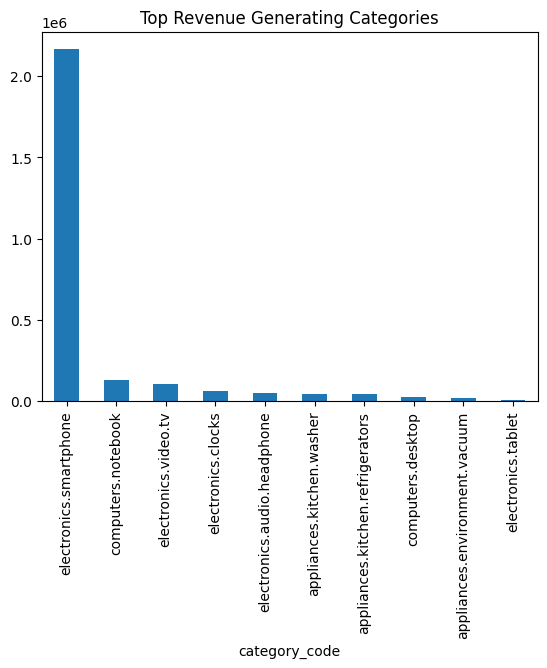

In [30]:
revenue.plot(kind='bar')
plt.title("Top Revenue Generating Categories")
plt.show()

In [31]:
user_activity = df.groupby('user_id')['event_type'].count()
print(user_activity.describe())

count    89124.000000
mean         5.610161
std          8.416450
min          1.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        249.000000
Name: event_type, dtype: float64


In [32]:
df.to_csv("ecommerce_sample.csv", index=False)